In [1]:
import pandas as pd
import numpy as np
import requests
import gdown
import pyarrow.parquet as pq

import yfinance as yf

import time
import matplotlib.pyplot as plt

from io import StringIO

plt.style.use("tableau-colorblind10")

Question 1: [IPO] Withdrawn IPOs by Company Type

What is the total withdrawn IPO value (in $ millions) for the company class with the highest total withdrawal value?

From the Recently Filed IPO list (iposcoop.com/ipos-recently-filed), collect and process the data to find out which company type saw the most withdrawn IPO value before Sep 11, 2026.

Steps:

Data Loading: Use pandas.read_html() with the URL above to load the IPO recently filed table. Filter the rows to keep only those where 'Expected To Trade' is 'Withdrawn'. You should identify 32 entries.

Company Classification: Create a new column called Company Type, categorizing company names based on patterns (order matters, assign the first matched value):

  * "Technologies" -> Technologies
  * "Acquisition Corp", "Acquisition Corporation", or "Corp" -> Acquisition Corp
  * "Inc" or "Incorporated" -> Inc.
  * "Group" -> Group
  * "Ltd" or "Limited" -> Limited
  * "Holdings" or "Holding" -> Holdings
  * Others -> Other

Price Parsing: Define a new field Avg_price by parsing the 'Price Low' and 'Price High' fields. Create a function to extract numeric values (e.g., '$8.00' -> 8.0) and calculate the average between low and high. Handle '-' or missing values as None/NaN.

Numeric Conversion: Convert Shares (millions) and Est `$` Vol (millions) to numeric formats, cleaning currency symbols `$` and commas where necessary.

Value Calculation: Create a new column Shares_offered_value:

  * If Shares (millions) * Avg_price is not null, use that value
  * Otherwise, use the value from the Est `$` Vol (millions) column

Aggregation: Group by Company Type and calculate the sum of Shares_offered_value.

Answer: Which class had the highest total value of withdrawals, and what was that value?

In [2]:
URL = "https://www.iposcoop.com/ipos-recently-filed/"
UA = {"User-Agent": "Mozilla/5.0"}

def get_ipo_recently_filed():
    try:
        response = requests.get(URL, headers=UA, timeout=10)
        response.raise_for_status()

        html_io = StringIO(response.text)
        tables = pd.read_html(html_io)

        if not tables:
            raise ValueError("No tables found")

        return tables[0]
    except requests.exceptions.RequestException as e:
        print(f"Request failed: {e}")
    except ValueError as ve:
        print(f"Data error: {ve}")
    except Exception as ex:
        print(f"Unexpected error: {ex}")

    return pd.DataFrame()

In [3]:
#get ipo data
ipo_data = get_ipo_recently_filed()
ipo_data.head()

,File Date,Company,Symbol,Managers,Shares (millions),Price Low,Price High,Est $ Vol (millions),Expected To Trade,SCOOP Rating
0,2026-09-24,ADARx Pharmaceuticals,ADRX,J.P.Morgan/Morgan Stanley/TD Cowen/UBS Investm...,26.25,$17.00,$17.00,$446.25,Priced,S/O
1,2026-09-24,Bluerock Acquisition Corp. II,BRRKU,BTIG,15.00,$10.00,$10.00,$150.00,Priced,S/O
2,2026-09-24,City Therapeutics,CTY,Goldman Sachs/Jefferies/Stifel/Oppenheimer & Co.,0.00,NaN,NaN,$100.00,TBA,S/O
3,2026-09-24,Hacker Interstellar,SOUD,Kingswood Capital Markets,3.90,$10.50,$11.50,$42.90,TBA,S/O
4,2026-09-24,New Iceland Arctic Acquisition Corp.,NIAAU,Chardan,12.50,$10.00,$10.00,$125.00,Week of,S/O


In [4]:
ipo_data.dtypes

File Date                   str
Company                     str
Symbol                      str
Managers                    str
Shares (millions)       float64
Price Low                   str
Price High                  str
Est $ Vol (millions)        str
Expected To Trade           str
SCOOP Rating                str
dtype: object

In [5]:
#turn str File Date to datetime
ipo_data["File Date"] = pd.to_datetime(ipo_data["File Date"], format="%Y-%m-%d")
ipo_data.head()

,File Date,Company,Symbol,Managers,Shares (millions),Price Low,Price High,Est $ Vol (millions),Expected To Trade,SCOOP Rating
0,2026-09-24,ADARx Pharmaceuticals,ADRX,J.P.Morgan/Morgan Stanley/TD Cowen/UBS Investm...,26.25,$17.00,$17.00,$446.25,Priced,S/O
1,2026-09-24,Bluerock Acquisition Corp. II,BRRKU,BTIG,15.00,$10.00,$10.00,$150.00,Priced,S/O
2,2026-09-24,City Therapeutics,CTY,Goldman Sachs/Jefferies/Stifel/Oppenheimer & Co.,0.00,NaN,NaN,$100.00,TBA,S/O
3,2026-09-24,Hacker Interstellar,SOUD,Kingswood Capital Markets,3.90,$10.50,$11.50,$42.90,TBA,S/O
4,2026-09-24,New Iceland Arctic Acquisition Corp.,NIAAU,Chardan,12.50,$10.00,$10.00,$125.00,Week of,S/O


In [6]:
#data before 2026-09-11
TARGET_DATE = "2026-09-11"

target_date_mask = ipo_data["File Date"] < TARGET_DATE
ipo_data_range = ipo_data[target_date_mask].copy().reset_index(drop=True)
ipo_data_range.head()

,File Date,Company,Symbol,Managers,Shares (millions),Price Low,Price High,Est $ Vol (millions),Expected To Trade,SCOOP Rating
0,2026-09-10,Allarity Acquisition Corp.,ALLNU,Maxim Group,10.0,$10.00,$10.00,$100.00,TBA,S/O
1,2026-09-10,Motive Technologies (Withdrawn),MTVE,J.P.Morgan/Citigroup/Barclays/Jefferies/RBC Ca...,0.0,NaN,NaN,$100.00,Withdrawn,S/O
2,2026-09-09,Elevation Acquisition Group,ELEVU,Maxim Group,10.0,$10.00,$10.00,$100.00,TBA,S/O
3,2026-09-09,Football Manager SPAC,FBLLU,D. Boral Capital,10.0,$10.00,$10.00,$100.00,TBA,S/O
4,2026-09-09,Harbour Island Acquisition Corp. I,HRIAU,Clear Street,10.0,$10.00,$10.00,$100.00,TBA,S/O


In [7]:
#keep only those where 'Expected To Trade' is 'Withdrawn'. You should identify 32 entries
withdrawn_mask = ipo_data_range["Expected To Trade"] == "Withdrawn"
ipo_data_range = ipo_data_range[withdrawn_mask].reset_index(drop=True)
ipo_data_range.shape


(31, 10)

In [8]:
ACQ_CORP = "Acquisition Corp"
TECH = "Technologies"
groups = {
    TECH: TECH,
    ACQ_CORP: ACQ_CORP,
    "Acquisition Corporation": ACQ_CORP,
    "Corp": ACQ_CORP,
    "Inc": "Inc",
    "Incorporated": "Inc",
    "Group": "Group",
    "Limited": "Limited",
    "Ltd": "Limited",
    "Holdings": "Holdings",
    "Holding": "Holdings",
    "Others": "Other"
}

grp_k = list(groups.keys())
grp_v = list(groups.values())
#get position of dict key in df column value, use T to have shape (n_rows, n_keys)
positions = np.array(
    [ipo_data_range["Company"].str.find(group_key) for group_key in grp_k]
).T
#when dict key is not found change -1 for a large number so it never gets picked
positions = np.where(positions < 0, np.inf, positions)
#use the earliest or best position found
best = positions.argmin(axis=1)
#filter only positions where one key was found ignore np.inf values
group_key_mask = positions.min(axis=1) < np.inf
#use index of best key, get value from grp_v, assign back only to True filtered values in df
ipo_data_range.loc[group_key_mask, "Company Type"] = np.array(grp_v)[best[group_key_mask]]
#fill missing with Other as no match was found from given options
ipo_data_range["Company Type"] = ipo_data_range["Company Type"].fillna("Other")

In [9]:
ipo_data_range[["Company", "Company Type"]]

,Company,Company Type
0,Motive Technologies (Withdrawn),Technologies
1,Idea Tech Holding (Withdrawn),Holdings
2,Hornbeck Offshore Services (Withdrawn),Other
3,Coolbit Technologies Ltd. (Withdrawn),Technologies
4,Timber Road Acquisition Corp. (Withdrawn),Acquisition Corp
5,pan-Africa Corp. (Withdrawn),Acquisition Corp
6,Living Homeopathy (Withdrawn),Other
7,Nuclea Energy (Withdrawn),Other
8,APEX Global Solutions Ltd. (WITHDRAWN),Limited
9,Cloud Data Holdings (Withdrawn),Holdings


In [10]:
ipo_data_range[["Price High", "Price Low", "Shares (millions)", "Est $ Vol (millions)"]].sample(10)

,Price High,Price Low,Shares (millions),Est $ Vol (millions)
5,$10.00,$10.00,12.50,$125.00
14,$5.00,$4.00,3.33,$15.00
30,$4.00,$4.00,1.50,$6.00
12,$17.00,$15.00,16.67,$266.72
2,NaN,NaN,0.00,$100.00
19,NaN,NaN,0.00,$15.00
26,$6.00,$4.00,2.00,$10.00
10,$10.00,$10.00,10.00,$100.00
17,$6.00,$4.00,1.25,$6.25
6,$6.00,$4.00,3.75,$19.00


In [11]:
def numeric_conversion(df:pd.DataFrame, columns: list[str]):
    #replace NaN with 0.0
    df[columns] = df[columns].replace(np.nan, 0.0)
    #remove $ symbol, cast to float
    df[columns] = df[columns].replace(r"\$", "", regex=True).astype(float)
    return df


In [12]:
#price parsing & numeric conversion
cols = ["Price High", "Price Low", "Shares (millions)", "Est $ Vol (millions)"]
ipo_data_range = numeric_conversion(ipo_data_range, columns=cols)

In [13]:
ipo_data_range[["Price High", "Price Low", "Shares (millions)", "Est $ Vol (millions)"]].sample(10)

,Price High,Price Low,Shares (millions),Est $ Vol (millions)
1,5.0,4.0,2.00,9.00
11,0.0,0.0,0.00,100.00
18,4.0,4.0,2.38,9.50
14,5.0,4.0,3.33,15.00
6,6.0,4.0,3.75,19.00
2,0.0,0.0,0.00,100.00
25,6.0,4.0,1.50,7.50
5,10.0,10.0,12.50,125.00
7,10.0,8.0,5.60,50.40
12,17.0,15.0,16.67,266.72


In [14]:
#Avg_price
ipo_data_range["Avg_price"] = ipo_data_range[["Price High", "Price Low"]].mean(axis=1)
ipo_data_range[["Price High", "Price Low", "Avg_price"]].head()

,Price High,Price Low,Avg_price
0,0.0,0.0,0.0
1,5.0,4.0,4.5
2,0.0,0.0,0.0
3,5.0,4.0,4.5
4,10.0,10.0,10.0


In [15]:
#value calculation
ipo_data_range["Shares_offered_value"] = np.where(
    ipo_data_range["Shares (millions)"] * ipo_data_range["Avg_price"] > 0,
    ipo_data_range["Shares (millions)"] * ipo_data_range["Avg_price"],
    ipo_data_range["Est $ Vol (millions)"]
)

ipo_data_range[["Avg_price", "Shares (millions)", "Est $ Vol (millions)", "Shares_offered_value"]].sample(10)

,Avg_price,Shares (millions),Est $ Vol (millions),Shares_offered_value
16,5.0,6.25,31.0,31.250
20,4.0,3.75,15.0,15.000
6,5.0,3.75,19.0,18.750
28,5.0,4.00,20.0,20.000
4,10.0,20.00,200.0,200.000
2,0.0,0.00,100.0,100.000
14,4.5,3.33,15.0,14.985
8,4.0,3.75,15.0,15.000
27,27.0,13.00,351.0,351.000
3,4.5,5.00,22.5,22.500


In [16]:
sum_of_shares_by_company_type = ipo_data_range.groupby(by=["Company Type"]).agg(
    sum_of_shares = ("Shares_offered_value", "sum")
)

In [17]:
sum_of_shares_by_company_type.sum_of_shares.sort_values(ascending=False)

Company Type
Acquisition Corp    499.9850
Group               383.5000
Holdings            341.6575
Other               290.4450
Technologies        184.9000
Limited             167.2500
Name: sum_of_shares, dtype: float64

Question 2: [IPO] Median Sharpe Ratio for 2025 IPOs (First 8 Months)

What is the median Sharpe ratio (as of 11 September 2026) for companies that went public before 1 September 2025?

The goal is to replicate the large-scale yfinance OHLCV data download and perform basic financial calculations on IPO stocks.

Steps:

Data Loading: Download the list of 231 IPOs in 2025 from https://www.iposcoop.com/2025-pricings/.

Filtering: Filter the list to keep only those IPOs with an 'Offer Date' before 1 September 2025. Also, exclude entries with a 0% return to ensure active tickers are processed. You should see 148 stocks.

Data Download: Use yfinance to download daily stock data for the filtered tickers and save it to the stocks_df dataframe. Make sure you can correctly process the cases when stocks are not present in Yahoo Finance (probably delisted). At this stage you should see about 134 stocks.

Feature Engineering:
  * Define growth_252d as Close / Close.shift(252) to represent growth after approximately one year of trading.

  * Calculate annualized volatility using the specific formula: stocks_df['volatility'] = stocks_df['Close'].rolling(30).std() * np.sqrt(252).

Sharpe Ratio Calculation: Calculate the Sharpe ratio assuming a risk-free rate of 5.0% (0.05) - it is close to the current value of the US 10Y Treasury bond yield:
  * stocks_df['Sharpe'] = (stocks_df['growth_252d'] - 0.05) / stocks_df['volatility']

Final Analysis: Filter the resulting DataFrame to keep data only for the trading day '2026-09-11' and compute descriptive statistics (using the describe() function).

Expected Observations:
  * Compare the median vs. mean for growth_252d to see if high-growth outliers are biasing the average.
  * Identify the count of stocks that successfully reached the 252-day trading milestone.
  * Do you see examples of stocks with risk-adjusted returns (Sharpe ratio) more attractive than pure growth statistics?

Answer: What is the median Sharpe ratio for these stocks as of September 11, 2026?

In [18]:
UA = {
    "User-Agent": "Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/153.0.0.0 Safari/537.36"
}
def get_ipos_by_year(year: int):
    url=f"https://www.iposcoop.com/{year}-pricings"
    try:
        response = requests.get(url, headers=UA, timeout=10)
        response.raise_for_status()

        html_io = StringIO(response.text)
        tables = pd.read_html(html_io)

        if not tables:
            raise ValueError(f"No tables found for year {year}.")

        return tables[0]
    except requests.exceptions.RequestException as e:
        print(f"Request failed: {e}")
    except ValueError as ve:
        print(f"Data error: {ve}")
    except Exception as ex:
        print(f"Unexpected error: {ex}")
    return pd.DataFrame()

In [19]:
ipos_2025 = get_ipos_by_year(2025)
ipos_2025.shape

(231, 10)

In [20]:
ipos_2025.head()

,Company,Symbol,Industry,Offer Date,Shares (millions),Offer Price,1st Day Close,Current Price,Return,SCOOP Rating
0,Vine Hill Capital Investment Corp. II,VHCPU,Blank Check,12/18/2025,20.0,$10.00,$0.00,$0.00,0.00%,S/O
1,Andersen Group,ANDG,Consumer Services,12/17/2025,11.0,$16.00,$23.50,$23.79,48.69%,S/O
2,Medline Inc.,MDLN,Health Care,12/17/2025,216.0,$29.00,$41.00,$43.83,51.14%,S/O
3,Wealthfront Corp.,WLTH,Financials,12/12/2025,34.6,$14.00,$14.19,$8.49,-39.36%,S/O
4,Lumexa Imaging Holdings,LMRI,Health Care,12/11/2025,25.0,$18.50,$18.52,$14.80,-20.00%,S/O


In [21]:
ipos_2025["Offer Date"] = pd.to_datetime(ipos_2025["Offer Date"], format="mixed")
ipos_2025["Offer Date"] = ipos_2025["Offer Date"].dt.strftime("%Y-%m-%d")

ipos_2025.head()

,Company,Symbol,Industry,Offer Date,Shares (millions),Offer Price,1st Day Close,Current Price,Return,SCOOP Rating
0,Vine Hill Capital Investment Corp. II,VHCPU,Blank Check,2025-12-18,20.0,$10.00,$0.00,$0.00,0.00%,S/O
1,Andersen Group,ANDG,Consumer Services,2025-12-17,11.0,$16.00,$23.50,$23.79,48.69%,S/O
2,Medline Inc.,MDLN,Health Care,2025-12-17,216.0,$29.00,$41.00,$43.83,51.14%,S/O
3,Wealthfront Corp.,WLTH,Financials,2025-12-12,34.6,$14.00,$14.19,$8.49,-39.36%,S/O
4,Lumexa Imaging Holdings,LMRI,Health Care,2025-12-11,25.0,$18.50,$18.52,$14.80,-20.00%,S/O


In [22]:
#Offer Date before 2025-09-01
TARGET_DATE = "2025-09-01"

target_date_mask = ipos_2025["Offer Date"] < TARGET_DATE
ipos_2025_range = ipos_2025[target_date_mask].copy().reset_index(drop=True)

ipos_2025_range.shape

(163, 10)

In [23]:
ipos_2025_range["num_return"] = ipos_2025_range["Return"].str.replace("%", "").astype(float)
ipos_2025_range.head()

,Company,Symbol,Industry,Offer Date,Shares (millions),Offer Price,1st Day Close,Current Price,Return,SCOOP Rating,num_return
0,"Picard Medical, Inc.",PMI,Health Care,2025-08-29,4.3,$4.00,$4.59,$1.68,-58.00%,S/O,-58.00
1,GrowHub Limited (The),TGHL,Technology,2025-08-28,3.7,$4.00,$3.38,$0.40,-90.00%,S/O,-90.00
2,TryHard Holdings Limited,THH,Consumer Services,2025-08-28,1.5,$4.00,$6.02,$29.47,636.75%,S/O,636.75
3,Curanex Pharmaceuticals,CURX,Health Care,2025-08-26,3.8,$4.00,$4.02,$0.37,-90.75%,S/O,-90.75
4,"Cantor Equity Partners IV, Inc. (Stock-Only SPAC)",CEPF,Blank Check,2025-08-21,40.0,$10.00,$10.12,$10.12,1.20%,S/O,1.20


In [24]:
#exclude 0% return
ipos_2025_range = ipos_2025_range[~(ipos_2025_range["num_return"] == 0.0)]
ipos_2025_range.shape

(146, 11)

In [25]:
tickers = ipos_2025_range["Symbol"].to_list()
len(tickers)

146

In [26]:
#DATE_START = "2025-01-01"
#date end is exclusive
#DATE_END = "2026-09-12"
ticker_data = yf.download(tickers, period="max", auto_adjust=True, interval="1d", progress=False)
#ticker_data = yf.download(tickers, start=DATE_START, end=DATE_END, auto_adjust=True, interval="1d", progress=False)
ticker_data = ticker_data[["Close"]]
ticker_data.head()

HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: MCTR"}}}
$MTSR: possibly delisted; no timezone found
HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: AHL"}}}
$MCTR: possibly delisted; no timezone found
$AHL: possibly delisted; no timezone found
$SKBL: possibly delisted; no timezone found
$TBH: possibly delisted; no timezone found
$EMPG: possibly delisted; no timezone found
$WGRX: No data found, symbol may be delisted
$MJID: possibly delisted; no timezone found
$SDM: possibly delisted; no timezone found
$CEPT: possibly delisted; no timezone found
$CAEP: possibly delisted; no timezone found
$EPWK: possibly delisted; no timezone found
$PTNM: possibly delisted; no timezone found
$AGH: possibly delisted; no timezone found

14 Failed downloads:
['MTSR', 'MCTR', 'AHL', 'SKBL', 'TBH', 'EMPG', 'MJID', 'SDM', 'CEPT', 'CAEP', 'EPWK', 'PTNM', 'AGH']: possibly d

Price      Close                                           ...                \
Ticker      AAPG AARD ADVB AGH AHL AII AIRO ALM AMBQ ANPA  ... WETO WFF WGRX   
Date                                                       ...                 
1993-01-28   NaN  NaN  NaN NaN NaN NaN  NaN NaN  NaN  NaN  ...  NaN NaN  NaN   
1993-01-29   NaN  NaN  NaN NaN NaN NaN  NaN NaN  NaN  NaN  ...  NaN NaN  NaN   
1993-02-01   NaN  NaN  NaN NaN NaN NaN  NaN NaN  NaN  NaN  ...  NaN NaN  NaN   
1993-02-02   NaN  NaN  NaN NaN NaN NaN  NaN NaN  NaN  NaN  ...  NaN NaN  NaN   
1993-02-03   NaN  NaN  NaN NaN NaN NaN  NaN NaN  NaN  NaN  ...  NaN NaN  NaN   

Price                                       
Ticker     WTF WXM WYFI XHLD YMAT YMT ZYBT  
Date                                        
1993-01-28 NaN NaN  NaN  NaN  NaN NaN  NaN  
1993-01-29 NaN NaN  NaN  NaN  NaN NaN  NaN  
1993-02-01 NaN NaN  NaN  NaN  NaN NaN  NaN  
1993-02-02 NaN NaN  NaN  NaN  NaN NaN  NaN  
1993-02-03 NaN NaN  NaN  NaN  NaN NaN  NaN  

[5 rows x 146 columns]

In [27]:
#remove all rows that are NaN or missing
stock_df = ticker_data.dropna(how="all")
#remove tickers that have all NaN or missing
stock_df = stock_df.dropna(axis=1, how="all")

In [28]:
stock_df.shape

(8473, 132)

In [29]:
stock_df.sample(10)

Price           Close                                                      \
Ticker           AAPG  AARD  ADVB        AII  AIRO        ALM   AMBQ ANPA   
Date                                                                        
2012-05-21        NaN   NaN   NaN        NaN   NaN        NaN    NaN  NaN   
2023-10-17        NaN   NaN   NaN        NaN   NaN   0.945000    NaN  NaN   
2001-08-30        NaN   NaN   NaN        NaN   NaN        NaN    NaN  NaN   
2002-04-25        NaN   NaN   NaN        NaN   NaN        NaN    NaN  NaN   
2026-06-25  17.049999  5.06  4.99  17.700001  6.72  16.450001  83.43  4.3   
2016-08-22        NaN   NaN   NaN        NaN   NaN   0.591750    NaN  NaN   
2022-10-25        NaN   NaN   NaN        NaN   NaN   1.017000    NaN  NaN   
1997-09-23        NaN   NaN   NaN        NaN   NaN        NaN    NaN  NaN   
2021-10-12        NaN   NaN   NaN        NaN   NaN   1.568250    NaN  NaN   
2007-08-29        NaN   NaN   NaN        NaN   NaN        NaN    NaN  NaN   

Price                  ...                                                   \
Ticker     ANTA  APUS  ...   VOYG  WETO   WFF   WTF  WXM   WYFI  XHLD  YMAT   
Date                   ...                                                    
2012-05-21  NaN   NaN  ...    NaN   NaN   NaN   NaN  NaN    NaN   NaN   NaN   
2023-10-17  NaN   NaN  ...    NaN   NaN   NaN   NaN  NaN    NaN   NaN   NaN   
2001-08-30  NaN   NaN  ...    NaN   NaN   NaN   NaN  NaN    NaN   NaN   NaN   
2002-04-25  NaN   NaN  ...    NaN   NaN   NaN   NaN  NaN    NaN   NaN   NaN   
2026-06-25  5.5  8.58  ...  29.32  86.5  2.82  2.62  4.6  36.82  1.21  3.26   
2016-08-22  NaN   NaN  ...    NaN   NaN   NaN   NaN  NaN    NaN   NaN   NaN   
2022-10-25  NaN   NaN  ...    NaN   NaN   NaN   NaN  NaN    NaN   NaN   NaN   
1997-09-23  NaN   NaN  ...    NaN   NaN   NaN   NaN  NaN    NaN   NaN   NaN   
2021-10-12  NaN   NaN  ...    NaN   NaN   NaN   NaN  NaN    NaN   NaN   NaN   
2007-08-29  NaN   NaN  ...    NaN   NaN   NaN   NaN  NaN    NaN   NaN   NaN   

Price                    
Ticker       YMT   ZYBT  
Date                     
2012-05-21   NaN    NaN  
2023-10-17   NaN    NaN  
2001-08-30   NaN    NaN  
2002-04-25   NaN    NaN  
2026-06-25  8.96  0.761  
2016-08-22   NaN    NaN  
2022-10-25   NaN    NaN  
1997-09-23   NaN    NaN  
2021-10-12   NaN    NaN  
2007-08-29   NaN    NaN  

[10 rows x 132 columns]

In [30]:
#feature engineering
"""
there are a lot of missing values in each ticker
not sure if remove/replace is ok here or keep the missing values
this is up to you as far as i can tell
"""
growth_252d = stock_df["Close"] / stock_df["Close"].shift(252, axis=0)
growth_252d.columns = pd.MultiIndex.from_product(
    [["growth_252d"], growth_252d.columns]
)
stock_df = pd.concat([stock_df, growth_252d], axis=1)
stock_df

Close                                                       \
Ticker        AAPG  AARD  ADVB        AII  AIRO    ALM       AMBQ  ANPA   
Date                                                                      
1993-01-28     NaN   NaN   NaN        NaN   NaN    NaN        NaN   NaN   
1993-01-29     NaN   NaN   NaN        NaN   NaN    NaN        NaN   NaN   
1993-02-01     NaN   NaN   NaN        NaN   NaN    NaN        NaN   NaN   
1993-02-02     NaN   NaN   NaN        NaN   NaN    NaN        NaN   NaN   
1993-02-03     NaN   NaN   NaN        NaN   NaN    NaN        NaN   NaN   
...            ...   ...   ...        ...   ...    ...        ...   ...   
2026-09-21  15.860  5.57  6.47  25.860001  7.18  14.66  71.089996  2.11   
2026-09-22  15.870  5.75  6.38  25.959999  7.24  14.35  71.050003  1.97   
2026-09-23  15.580  5.56  6.32  24.969999  7.16  13.62  69.129997  1.97   
2026-09-24  15.230  5.55  6.31  25.330000  7.21  12.40  68.919998  2.07   
2026-09-25  14.856  5.06  6.38  25.190001  7.24  13.72  69.790001  2.00   

                         ... growth_252d                                \
Ticker       ANTA  APUS  ...        VOYG      WETO       WFF       WTF   
Date                     ...                                             
1993-01-28    NaN   NaN  ...         NaN       NaN       NaN       NaN   
1993-01-29    NaN   NaN  ...         NaN       NaN       NaN       NaN   
1993-02-01    NaN   NaN  ...         NaN       NaN       NaN       NaN   
1993-02-02    NaN   NaN  ...         NaN       NaN       NaN       NaN   
1993-02-03    NaN   NaN  ...         NaN       NaN       NaN       NaN   
...           ...   ...  ...         ...       ...       ...       ...   
2026-09-21  3.150  1.67  ...    1.265457  0.007097  0.488449  0.377976   
2026-09-22  3.200  1.85  ...    1.295478  0.007301  0.452747  0.375185   
2026-09-23  3.100  2.29  ...    0.961421  0.007005  0.464646  0.376563   
2026-09-24  2.915  4.92  ...    0.976452  0.009157  0.467269  0.355522   
2026-09-25  2.840  7.25  ...    1.028206  0.008814  0.545455  0.368816   

                                                                        
Ticker           WXM      WYFI      XHLD      YMAT       YMT      ZYBT  
Date                                                                    
1993-01-28       NaN       NaN       NaN       NaN       NaN       NaN  
1993-01-29       NaN       NaN       NaN       NaN       NaN       NaN  
1993-02-01       NaN       NaN       NaN       NaN       NaN       NaN  
1993-02-02       NaN       NaN       NaN       NaN       NaN       NaN  
1993-02-03       NaN       NaN       NaN       NaN       NaN       NaN  
...              ...       ...       ...       ...       ...       ...  
2026-09-21  0.113405  0.848355  2.081592  0.217323  0.003512  0.142555  
2026-09-22  0.116384  0.769202  2.482540  0.165000  0.003759  0.138678  
2026-09-23  0.116618  0.679871  2.493292  0.163057  0.003583  0.156840  
2026-09-24  0.111392  0.721767  2.645833  0.210294  0.003583  0.187411  
2026-09-25  0.106667  0.747429  2.672859  0.243750  0.003752  0.262575  

[8473 rows x 264 columns]

In [31]:
volatility = stock_df["Close"].rolling(30).std() * np.sqrt(252)
volatility.columns = pd.MultiIndex.from_product(
    [["volatility"], volatility.columns]
)
stock_df = pd.concat([stock_df, volatility], axis=1)
stock_df

Close                                                       \
Ticker        AAPG  AARD  ADVB        AII  AIRO    ALM       AMBQ  ANPA   
Date                                                                      
1993-01-28     NaN   NaN   NaN        NaN   NaN    NaN        NaN   NaN   
1993-01-29     NaN   NaN   NaN        NaN   NaN    NaN        NaN   NaN   
1993-02-01     NaN   NaN   NaN        NaN   NaN    NaN        NaN   NaN   
1993-02-02     NaN   NaN   NaN        NaN   NaN    NaN        NaN   NaN   
1993-02-03     NaN   NaN   NaN        NaN   NaN    NaN        NaN   NaN   
...            ...   ...   ...        ...   ...    ...        ...   ...   
2026-09-21  15.860  5.57  6.47  25.860001  7.18  14.66  71.089996  2.11   
2026-09-22  15.870  5.75  6.38  25.959999  7.24  14.35  71.050003  1.97   
2026-09-23  15.580  5.56  6.32  24.969999  7.16  13.62  69.129997  1.97   
2026-09-24  15.230  5.55  6.31  25.330000  7.21  12.40  68.919998  2.07   
2026-09-25  14.856  5.06  6.38  25.190001  7.24  13.72  69.790001  2.00   

                         ... volatility                                  \
Ticker       ANTA  APUS  ...       VOYG        WETO       WFF       WTF   
Date                     ...                                              
1993-01-28    NaN   NaN  ...        NaN         NaN       NaN       NaN   
1993-01-29    NaN   NaN  ...        NaN         NaN       NaN       NaN   
1993-02-01    NaN   NaN  ...        NaN         NaN       NaN       NaN   
1993-02-02    NaN   NaN  ...        NaN         NaN       NaN       NaN   
1993-02-03    NaN   NaN  ...        NaN         NaN       NaN       NaN   
...           ...   ...  ...        ...         ...       ...       ...   
2026-09-21  3.150  1.67  ...  61.837435  163.227408  3.078939  2.465033   
2026-09-22  3.200  1.85  ...  59.108268  164.333056  2.910363  2.533064   
2026-09-23  3.100  2.29  ...  58.016166  165.383495  2.919187  2.701268   
2026-09-24  2.915  4.92  ...  56.334169  166.113019  2.738060  2.842145   
2026-09-25  2.840  7.25  ...  51.958187  166.777073  2.764407  2.844300   

                                                                            
Ticker            WXM       WYFI       XHLD      YMAT        YMT      ZYBT  
Date                                                                        
1993-01-28        NaN        NaN        NaN       NaN        NaN       NaN  
1993-01-29        NaN        NaN        NaN       NaN        NaN       NaN  
1993-02-01        NaN        NaN        NaN       NaN        NaN       NaN  
1993-02-02        NaN        NaN        NaN       NaN        NaN       NaN  
1993-02-03        NaN        NaN        NaN       NaN        NaN       NaN  
...               ...        ...        ...       ...        ...       ...  
2026-09-21  11.710227  62.303057  33.083315  3.715502  11.649625  2.957064  
2026-09-22  11.672440  61.854870  30.600353  3.983843  10.179311  3.075903  
2026-09-23   5.708651  61.273148  28.247994  4.232363  10.158828  3.154014  
2026-09-24   5.687097  56.603200  28.247240  4.319748   9.854939  3.263635  
2026-09-25   5.639593  51.647875  28.133296  4.296875   9.556930  3.365923  

[8473 rows x 396 columns]

In [32]:
#sharpe ratio
RFR = 0.05
sharpe = (stock_df["growth_252d"] - RFR) / stock_df["volatility"]
sharpe.columns = pd.MultiIndex.from_product(
    [["Sharpe"], sharpe.columns]
)
stock_df = pd.concat([stock_df, sharpe], axis=1)
stock_df

Close                                                       \
Ticker        AAPG  AARD  ADVB        AII  AIRO    ALM       AMBQ  ANPA   
Date                                                                      
1993-01-28     NaN   NaN   NaN        NaN   NaN    NaN        NaN   NaN   
1993-01-29     NaN   NaN   NaN        NaN   NaN    NaN        NaN   NaN   
1993-02-01     NaN   NaN   NaN        NaN   NaN    NaN        NaN   NaN   
1993-02-02     NaN   NaN   NaN        NaN   NaN    NaN        NaN   NaN   
1993-02-03     NaN   NaN   NaN        NaN   NaN    NaN        NaN   NaN   
...            ...   ...   ...        ...   ...    ...        ...   ...   
2026-09-21  15.860  5.57  6.47  25.860001  7.18  14.66  71.089996  2.11   
2026-09-22  15.870  5.75  6.38  25.959999  7.24  14.35  71.050003  1.97   
2026-09-23  15.580  5.56  6.32  24.969999  7.16  13.62  69.129997  1.97   
2026-09-24  15.230  5.55  6.31  25.330000  7.21  12.40  68.919998  2.07   
2026-09-25  14.856  5.06  6.38  25.190001  7.24  13.72  69.790001  2.00   

                         ...    Sharpe                                \
Ticker       ANTA  APUS  ...      VOYG      WETO       WFF       WTF   
Date                     ...                                           
1993-01-28    NaN   NaN  ...       NaN       NaN       NaN       NaN   
1993-01-29    NaN   NaN  ...       NaN       NaN       NaN       NaN   
1993-02-01    NaN   NaN  ...       NaN       NaN       NaN       NaN   
1993-02-02    NaN   NaN  ...       NaN       NaN       NaN       NaN   
1993-02-03    NaN   NaN  ...       NaN       NaN       NaN       NaN   
...           ...   ...  ...       ...       ...       ...       ...   
2026-09-21  3.150  1.67  ...  0.019656 -0.000263  0.142403  0.133051   
2026-09-22  3.200  1.85  ...  0.021071 -0.000260  0.138384  0.128376   
2026-09-23  3.100  2.29  ...  0.015710 -0.000260  0.142042  0.120892   
2026-09-24  2.915  4.92  ...  0.016446 -0.000246  0.152396  0.107497   
2026-09-25  2.840  7.25  ...  0.018827 -0.000247  0.179226  0.112089   

                                                                        
Ticker           WXM      WYFI      XHLD      YMAT       YMT      ZYBT  
Date                                                                    
1993-01-28       NaN       NaN       NaN       NaN       NaN       NaN  
1993-01-29       NaN       NaN       NaN       NaN       NaN       NaN  
1993-02-01       NaN       NaN       NaN       NaN       NaN       NaN  
1993-02-02       NaN       NaN       NaN       NaN       NaN       NaN  
1993-02-03       NaN       NaN       NaN       NaN       NaN       NaN  
...              ...       ...       ...       ...       ...       ...  
2026-09-21  0.005414  0.012814  0.061408  0.045034 -0.003991  0.031300  
2026-09-22  0.005687  0.011627  0.079494  0.028867 -0.004543  0.028830  
2026-09-23  0.011670  0.010280  0.086494  0.026713 -0.004569  0.033874  
2026-09-24  0.010795  0.011868  0.091897  0.037107 -0.004710  0.042104  
2026-09-25  0.010048  0.013504  0.093230  0.045091 -0.004839  0.063155  

[8473 rows x 528 columns]

In [33]:
#final analysis, date 2026-09-11
df_260911 = stock_df.loc["2026-09-11"]

In [34]:
#Compare median vs mean for growth_252d see if high-growth outliers are biasing the average
growth_252d_df = df_260911.growth_252d.describe()

In [35]:
growth_252d_df[["mean", "50%"]]

mean    1.063281
50%     0.596026
Name: 2026-09-11 00:00:00, dtype: float64

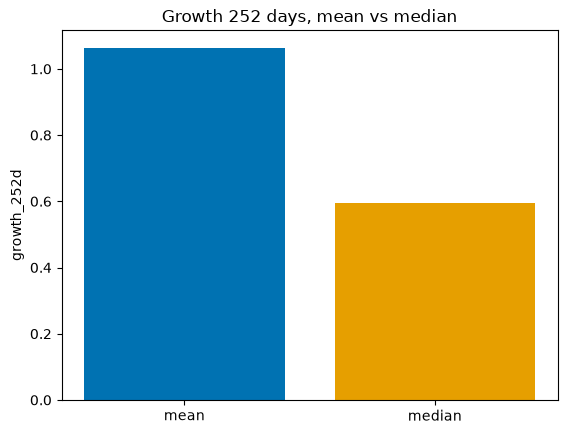

In [36]:
fig, ax = plt.subplots()

colors = ["#0072B2", "#E69F00"]
ax.bar(["mean", "median"], growth_252d_df[["mean", "50%"]], color=colors)

ax.set_ylabel("growth_252d")
ax.set_title("Growth 252 days, mean vs median")

plt.show()

In [37]:
#count of stocks that reached the 252d trading milestone
df_260911.growth_252d.notna().sum()

np.int64(131)

In [38]:
#median Sharpe ratio for these stocks as of 2026-09-11
sharpe_df_median = df_260911.Sharpe.median()
sharpe_df_median

np.float64(0.050142446812154115)

In [39]:
#stocks with risk-adjusted returns (Sharpe ratio) more attractive than pure growth statistics
#remove np.inf from sharpe
sharpe_finite = df_260911.Sharpe[np.isfinite(df_260911.Sharpe)]
sharpe_finite_tickers = sharpe_finite.index.to_list()
#use previous mask to filter finite growth_252d values
growth_finite = df_260911.growth_252d[np.isfinite(df_260911.Sharpe)]
growth_finite_tickers = growth_finite.index.to_list()
#check final tickers are the same
sharpe_finite_tickers == growth_finite_tickers

True

In [40]:
#normalized sharpe and growth_252d to z-scores, then take the difference to reduce to a scalar
z_score_sharpe_growth = (sharpe_finite - sharpe_finite.mean()) / sharpe_finite.std() \
- (growth_finite - growth_finite.mean()) / growth_finite.std()

z_score_sharpe_growth_df = pd.DataFrame({
    "ticker": z_score_sharpe_growth.index,
    "z_score_growth_sharpe": z_score_sharpe_growth.values
})

z_score_sharpe_growth_df

,ticker,z_score_growth_sharpe
0,AAPG,0.106558
1,AARD,0.032108
2,ADVB,-0.027050
3,AII,-0.221992
4,AIRO,0.120461
...,...,...
123,WYFI,-0.024103
124,XHLD,-0.564252
125,YMAT,0.146747
126,YMT,0.242234


In [41]:
#keep positive z_scores (sharpe is more attractive than growth)
z_score_mask = z_score_sharpe_growth_df.z_score_growth_sharpe > 0
attractive_sharpe = z_score_sharpe_growth_df[z_score_mask]
attractive_sharpe.sort_values(by="z_score_growth_sharpe", ascending=False).head(10)

,ticker,z_score_growth_sharpe
71,MAGH,9.759501
58,INLF,0.243241
126,YMT,0.242234
107,TDIC,0.242019
83,NCT,0.240786
80,MIMI,0.240022
119,WETO,0.239997
69,LHSW,0.239363
15,BIYA,0.239228
36,DGNX,0.238230


Note: Removing np.inf does not mean 'safe'. A stock with volatility 0.5% but not exactly zero could produce a Sharpe of 50-100. That single value will inflate mean and std, compressing all the other z-scores to zero.

Alternative, Robust z-score, this way a Sharpe of 50 won't distort the rest of the distribution.

### Trying to back up what i found

A Sharpe ratio being "more attractive" than raw growth statistics does not mean the Sharpe ratio value is greater than the annualized return (often represented by the 252-day annualized growth rate).

The Sharpe ratio and annualized return measure fundamentally different things and are not directly comparable in magnitude:

  * Annualized Return (Growth): This is a percentage (e.g., 15%) representing the average yearly profit. It can be any positive or negative number.
  * Sharpe Ratio: This is a unitless coefficient (e.g., 1.5) representing the excess return per unit of risk (volatility).
​

Key Distinctions:

  * An investment can have a high Sharpe ratio (e.g., 2.0, indicating excellent risk-adjusted performance) but a low annualized return (e.g., 6%). 
  * Conversely, an investment can have a low Sharpe ratio (e.g., 0.5, indicating poor risk-adjusted performance) but a high annualized return (e.g., 30%), if that return comes with extreme volatility.

Investors prefer a higher Sharpe ratio because it indicates they are getting more return for each unit of risk taken, not because the Sharpe number itself is larger than the return percentage.

The classic case is a stock with moderate but very consistent returns and low volatility. Its Sharpe ratio ends up higher than what its raw growth number alone would suggest, because the denominator (volatility) is small.

The point is that a stock's raw 252-day growth rate tells you how much it went up, but the Sharpe tells you how smoothly it got there. A stock that grows 10% steadily will often have a more attractive Sharpe than one that grows 25% with wild swings even though the raw number looks worse.

Question 3: [IPO] 'Fixed Months Holding Strategy'

What is the optimal number of months (1 to 12) to hold a newly IPO'd stock in order to maximize the median growth value?

Goal:

Investigate the performance of 2025 IPO stocks over fixed time horizons (1 to 12 months) to identify the holding period that yields the highest median return relative to the first day's closing price.

Steps:

Data Source: Use the existing stocks_df containing daily OHLCV data and calculated features for the 2025 IPOs filtered in Question 2.

Feature Engineering: Calculate 12 future growth columns representing fixed holding periods:
future_growth_1_m, future_growth_2_m, ..., future_growth_12_m. Assume 1 month equals 21 trading days (e.g., 1 month = 21 days, 2 months = 42 days, ..., 12 months = 252 days).

Identify Entry Points: For each ticker, determine the first available trading day (min_date) and the corresponding closing price.

Data Alignment: Perform an inner join between the min_date records and the full growth dataset. This isolates the returns for each stock starting specifically from its IPO date.

Median Analysis: Compute descriptive statistics for these 12 columns. Specifically, identify the month where the 50th percentile (median) value is highest.

Observations:
  * Do you observe any trend of the median growth over time? What does it mean for an investor eager to base their strategy on the newly IPOed companies?
  * Compare the median to the mean to understand how extreme outliers (high-growth stocks) affect the average versus the typical stock's performance.
  
Answer: Based on the analysis of the filtered tickers, what is the optimal holding period (in months) and its corresponding maximum median growth value?

In [42]:
stock_df.Close

Ticker,AAPG,AARD,ADVB,AII,AIRO,ALM,AMBQ,ANPA,ANTA,APUS,...,VOYG,WETO,WFF,WTF,WXM,WYFI,XHLD,YMAT,YMT,ZYBT
Date,,,,,,,,,,,,,,,,,,,,,
1993-01-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1993-01-29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1993-02-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1993-02-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1993-02-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-09-21,15.860,5.57,6.47,25.860001,7.18,14.66,71.089996,2.11,3.150,1.67,...,37.660000,1.65,2.22,2.54,4.23,19.860001,10.46,1.38,1.93,1.350
2026-09-22,15.870,5.75,6.38,25.959999,7.24,14.35,71.050003,1.97,3.200,1.85,...,37.529999,1.65,2.06,2.54,4.12,20.230000,11.73,1.32,2.03,1.280
2026-09-23,15.580,5.56,6.32,24.969999,7.16,13.62,69.129997,1.97,3.100,2.29,...,31.400000,1.45,2.07,2.41,4.00,19.049999,12.08,1.28,1.84,1.370


In [43]:
#12 future growth columns
TRADING_DAYS = 21
columns = []
for month in range(1, 13):
    name = "growth_"+str(month*TRADING_DAYS)+"d"
    columns.append(name)
    growth = stock_df.Close.shift(-(month*TRADING_DAYS)) / stock_df.Close
    growth.columns = pd.MultiIndex.from_product(
        [[name], growth.columns]
    )
    stock_df = pd.concat([stock_df, growth], axis=1)

In [44]:
#identify entry points, first available trading day close prices for each ticker
trading_days = stock_df.Close.apply(lambda column : column.first_valid_index())
trading_days

Ticker
AAPG   2025-01-24
AARD   2025-02-13
ADVB   2025-03-06
AII    2025-05-08
AIRO   2025-06-13
          ...    
WYFI   2025-08-07
XHLD   2025-02-13
YMAT   2025-07-30
YMT    2025-08-19
ZYBT   2025-01-07
Length: 132, dtype: datetime64[s]

In [45]:
close_prices = stock_df.Close.apply(lambda column : column[column.first_valid_index()])
close_prices

Ticker
AAPG     17.379999
AARD     14.310000
ADVB     73.000000
AII      16.008226
AIRO     24.000000
           ...    
WYFI     16.219999
XHLD    102.000000
YMAT     20.400000
YMT     672.000000
ZYBT      4.860000
Length: 132, dtype: float64

In [46]:
entry_date_price_df = pd.DataFrame({
    "ticker": trading_days.index,
    "close": close_prices.values,
    "date": pd.to_datetime(trading_days.values, format="%Y-%m-%d")
})

entry_date_price_df

,ticker,close,date
0,AAPG,17.379999,2025-01-24
1,AARD,14.310000,2025-02-13
2,ADVB,73.000000,2025-03-06
3,AII,16.008226,2025-05-08
4,AIRO,24.000000,2025-06-13
...,...,...,...
127,WYFI,16.219999,2025-08-07
128,XHLD,102.000000,2025-02-13
129,YMAT,20.400000,2025-07-30
130,YMT,672.000000,2025-08-19


In [47]:
future_growth_df = stock_df[columns].copy()

In [48]:
future_growth_df

growth_21d                                             ...  \
Ticker           AAPG AARD ADVB AII AIRO ALM AMBQ ANPA ANTA APUS  ...   
Date                                                              ...   
1993-01-28        NaN  NaN  NaN NaN  NaN NaN  NaN  NaN  NaN  NaN  ...   
1993-01-29        NaN  NaN  NaN NaN  NaN NaN  NaN  NaN  NaN  NaN  ...   
1993-02-01        NaN  NaN  NaN NaN  NaN NaN  NaN  NaN  NaN  NaN  ...   
1993-02-02        NaN  NaN  NaN NaN  NaN NaN  NaN  NaN  NaN  NaN  ...   
1993-02-03        NaN  NaN  NaN NaN  NaN NaN  NaN  NaN  NaN  NaN  ...   
...               ...  ...  ...  ..  ...  ..  ...  ...  ...  ...  ...   
2026-09-21        NaN  NaN  NaN NaN  NaN NaN  NaN  NaN  NaN  NaN  ...   
2026-09-22        NaN  NaN  NaN NaN  NaN NaN  NaN  NaN  NaN  NaN  ...   
2026-09-23        NaN  NaN  NaN NaN  NaN NaN  NaN  NaN  NaN  NaN  ...   
2026-09-24        NaN  NaN  NaN NaN  NaN NaN  NaN  NaN  NaN  NaN  ...   
2026-09-25        NaN  NaN  NaN NaN  NaN NaN  NaN  NaN  NaN  NaN  ...   

           growth_252d                                           
Ticker            VOYG WETO WFF WTF WXM WYFI XHLD YMAT YMT ZYBT  
Date                                                             
1993-01-28         NaN  NaN NaN NaN NaN  NaN  NaN  NaN NaN  NaN  
1993-01-29         NaN  NaN NaN NaN NaN  NaN  NaN  NaN NaN  NaN  
1993-02-01         NaN  NaN NaN NaN NaN  NaN  NaN  NaN NaN  NaN  
1993-02-02         NaN  NaN NaN NaN NaN  NaN  NaN  NaN NaN  NaN  
1993-02-03         NaN  NaN NaN NaN NaN  NaN  NaN  NaN NaN  NaN  
...                ...  ...  ..  ..  ..  ...  ...  ...  ..  ...  
2026-09-21         NaN  NaN NaN NaN NaN  NaN  NaN  NaN NaN  NaN  
2026-09-22         NaN  NaN NaN NaN NaN  NaN  NaN  NaN NaN  NaN  
2026-09-23         NaN  NaN NaN NaN NaN  NaN  NaN  NaN NaN  NaN  
2026-09-24         NaN  NaN NaN NaN NaN  NaN  NaN  NaN NaN  NaN  
2026-09-25         NaN  NaN NaN NaN NaN  NaN  NaN  NaN NaN  NaN  

[8473 rows x 1716 columns]

In [49]:
future_growth_df.columns

MultiIndex([( 'growth_21d', 'AAPG'),
            ( 'growth_21d', 'AARD'),
            ( 'growth_21d', 'ADVB'),
            ( 'growth_21d',  'AII'),
            ( 'growth_21d', 'AIRO'),
            ( 'growth_21d',  'ALM'),
            ( 'growth_21d', 'AMBQ'),
            ( 'growth_21d', 'ANPA'),
            ( 'growth_21d', 'ANTA'),
            ( 'growth_21d', 'APUS'),
            ...
            ('growth_252d', 'VOYG'),
            ('growth_252d', 'WETO'),
            ('growth_252d',  'WFF'),
            ('growth_252d',  'WTF'),
            ('growth_252d',  'WXM'),
            ('growth_252d', 'WYFI'),
            ('growth_252d', 'XHLD'),
            ('growth_252d', 'YMAT'),
            ('growth_252d',  'YMT'),
            ('growth_252d', 'ZYBT')],
           names=[None, 'Ticker'], length=1716)

In [50]:
future_growth_df.columns = [f"{c1}_{c2}" for c1, c2 in future_growth_df.columns]
future_growth_df.columns

Index(['growth_21d_AAPG', 'growth_21d_AARD', 'growth_21d_ADVB',
       'growth_21d_AII', 'growth_21d_AIRO', 'growth_21d_ALM',
       'growth_21d_AMBQ', 'growth_21d_ANPA', 'growth_21d_ANTA',
       'growth_21d_APUS',
       ...
       'growth_252d_VOYG', 'growth_252d_WETO', 'growth_252d_WFF',
       'growth_252d_WTF', 'growth_252d_WXM', 'growth_252d_WYFI',
       'growth_252d_XHLD', 'growth_252d_YMAT', 'growth_252d_YMT',
       'growth_252d_ZYBT'],
      dtype='str', length=1716)

In [51]:
future_growth_df = future_growth_df.reset_index().rename(columns={"index": "date"})
future_growth_df.rename(columns={"Date": "date"}, inplace=True)

In [52]:
future_growth_df

,date,growth_21d_AAPG,growth_21d_AARD,growth_21d_ADVB,growth_21d_AII,growth_21d_AIRO,growth_21d_ALM,growth_21d_AMBQ,growth_21d_ANPA,growth_21d_ANTA,...,growth_252d_VOYG,growth_252d_WETO,growth_252d_WFF,growth_252d_WTF,growth_252d_WXM,growth_252d_WYFI,growth_252d_XHLD,growth_252d_YMAT,growth_252d_YMT,growth_252d_ZYBT
0,1993-01-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1993-01-29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1993-02-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1993-02-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1993-02-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8468,2026-09-21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8469,2026-09-22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8470,2026-09-23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8471,2026-09-24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [53]:
melted_df = future_growth_df.melt(
    id_vars=["date"],
    var_name="future_value",
    value_name="growth_value"
)

In [54]:
melted_df[["growth_period", "ticker"]] = melted_df["future_value"].str.rsplit("_", n=1, expand=True)
melted_df = melted_df.drop("future_value", axis=1)

In [55]:
melted_df.columns = melted_df.columns.str.lower()
melted_df.columns

Index(['date', 'growth_value', 'growth_period', 'ticker'], dtype='str')

In [56]:
#join dfs using ticker and date
fut_growth_entry_date_df = melted_df.merge(entry_date_price_df, on=["date", "ticker"], how="inner")
fut_growth_entry_date_df

,date,growth_value,growth_period,ticker,close
0,2025-01-24,1.159954,growth_21d,AAPG,17.379999
1,2025-02-13,0.647100,growth_21d,AARD,14.310000
2,2025-03-06,0.920548,growth_21d,ADVB,73.000000
3,2025-05-08,1.005917,growth_21d,AII,16.008226
4,2025-06-13,1.085417,growth_21d,AIRO,24.000000
...,...,...,...,...,...
1711,2025-08-07,1.456227,growth_252d,WYFI,16.219999
1712,2025-02-13,0.020588,growth_252d,XHLD,102.000000
1713,2025-07-30,0.092157,growth_252d,YMAT,20.400000
1714,2025-08-19,0.004833,growth_252d,YMT,672.000000


In [57]:
g_means = []
g_medians = []
for growth in columns:
    growth_mask = fut_growth_entry_date_df["growth_period"]==growth
    g_means.append(fut_growth_entry_date_df[growth_mask].growth_value.mean())
    g_medians.append(fut_growth_entry_date_df[growth_mask].growth_value.median())

growth_stats = pd.DataFrame({
    "growth_period": columns,
    "g_mean": g_means,
    "g_median": g_medians
})

growth_stats

,growth_period,g_mean,g_median
0,growth_21d,1.119635,0.935351
1,growth_42d,1.294861,0.890411
2,growth_63d,1.252014,0.827160
3,growth_84d,1.135939,0.741678
4,growth_105d,1.084528,0.667857
5,growth_126d,1.114789,0.726000
6,growth_147d,1.146371,0.662000
7,growth_168d,1.004473,0.603508
8,growth_189d,1.158480,0.580294
9,growth_210d,1.185497,0.533333


In [58]:
growth_stats.loc[growth_stats.g_median.idxmax()]

growth_period    growth_21d
g_mean             1.119635
g_median           0.935351
Name: 0, dtype: object

### Avoid MultiIndex

In [59]:
len(tickers)

146

In [60]:
stocks_df = pd.DataFrame()

for ticker in tickers:
    #get ticker available data
    ticker_yf = yf.Ticker(ticker)
    ticker_data = ticker_yf.history(period="max", interval="1d")
    ticker_data = ticker_data[["Close"]]
    #useful features
    ticker_data["ticker"] = ticker
    ticker_data["date"] = pd.to_datetime(ticker_data.index, format="%Y-%m-%d").date
    #future growth periods
    growth_periods = [TRADING_DAYS * month for month in range(1, 13)]
    for days in growth_periods:
        period = "growth_"+str(days)+"_d"
        ticker_data[period] = ticker_data["Close"].shift(-days) / ticker_data["Close"]
    #pause
    time.sleep(0.25)

    if stocks_df.empty:
        stocks_df = ticker_data
    else:
        stocks_df = pd.concat([stocks_df, ticker_data], ignore_index=True)


$MJID: possibly delisted; no timezone found
$EMPG: possibly delisted; no timezone found
$CAEP: possibly delisted; no timezone found
$PTNM: possibly delisted; no timezone found
$AHL: possibly delisted; no timezone found
$CEPT: possibly delisted; no timezone found
$SDM: possibly delisted; no timezone found
$TBH: possibly delisted; no timezone found
$WGRX: No data found, symbol may be delisted
$AGH: possibly delisted; no timezone found
$EPWK: possibly delisted; no timezone found
$MTSR: possibly delisted; no timezone found
$SKBL: possibly delisted; no timezone found
$MCTR: possibly delisted; no timezone found


In [61]:
stocks_df.ticker.unique().shape

(132,)

In [62]:
#remove all rows that are NaN or missing
stocks_df = stocks_df.dropna(how="all")
#remove tickers that have all NaN or missing
stocks_df = stocks_df.dropna(axis=1, how="all")

In [63]:
stocks_df.ticker.unique().shape

(132,)

In [64]:
stocks_df["growth_252d"] = stocks_df["Close"] / stocks_df["Close"].shift(252)
stocks_df["volatility"] = stocks_df["Close"].rolling(30).std() * np.sqrt(252)
stocks_df["sharpe"] = (stocks_df["growth_252d"] - RFR) / stocks_df["volatility"]

In [65]:
stocks_df.date = pd.to_datetime(stocks_df.date, format="%Y-%m-%d")

In [66]:
stocks_df.dtypes

Close                 float64
ticker                    str
date            datetime64[s]
growth_21_d           float64
growth_42_d           float64
growth_63_d           float64
growth_84_d           float64
growth_105_d          float64
growth_126_d          float64
growth_147_d          float64
growth_168_d          float64
growth_189_d          float64
growth_210_d          float64
growth_231_d          float64
growth_252_d          float64
growth_252d           float64
volatility            float64
sharpe                float64
dtype: object

In [67]:
FILTER_DATE = "2026-09-11"
stocks_df[stocks_df.date == FILTER_DATE][["growth_252d", "sharpe"]].describe()

/media/chrisred83/ssd960/git_cleall/python/sm_az_26_lab/.venv/lib/python3.12/site-packages/pandas/core/nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,growth_252d,sharpe
count,132.000000,132.000000
mean,1.074837,inf
std,3.040746,NaN
min,0.001005,-0.040146
25%,0.133973,0.011303
50%,0.594534,0.050142
75%,1.045655,0.136059
max,33.638270,inf


In [68]:
min_date_df = stocks_df.groupby(["ticker"])["date"].min().reset_index()
min_date_stocks_df = stocks_df.merge(min_date_df, on=["ticker", "date"], how="inner")

In [69]:
min_date_stocks_stats = min_date_stocks_df[[f"growth_{str(TRADING_DAYS * month)}_d" for month in range(1, 13)]].describe()

In [70]:
min_date_stocks_stats

,growth_21_d,growth_42_d,growth_63_d,growth_84_d,growth_105_d,growth_126_d,growth_147_d,growth_168_d,growth_189_d,growth_210_d,growth_231_d,growth_252_d
count,132.000000,131.000000,131.000000,131.000000,131.000000,131.000000,131.000000,131.000000,131.000000,131.000000,131.000000,131.000000
mean,1.119635,1.294861,1.252014,1.135939,1.084528,1.114789,1.146371,1.004473,1.158480,1.185497,1.068597,0.973337
std,1.254616,1.957999,1.912626,1.558464,1.468733,1.668273,2.278159,2.046907,2.999642,3.422082,2.161964,2.127421
min,0.072941,0.106197,0.090147,0.063927,0.032245,0.022075,0.013229,0.015130,0.014675,0.011947,0.008681,0.004833
25%,0.708835,0.584863,0.442477,0.392759,0.400704,0.308026,0.245548,0.200983,0.174587,0.174333,0.159666,0.159567
50%,0.935351,0.890411,0.827160,0.741678,0.667857,0.726000,0.662000,0.603508,0.580294,0.533333,0.492453,0.551321
75%,1.098038,1.152849,1.149994,1.203576,1.083509,1.056403,1.019297,1.036588,1.031006,1.034765,1.106045,1.057691
max,9.466019,16.066783,16.344464,11.386643,9.495146,9.894552,20.741478,21.370826,27.627298,34.687666,19.595802,22.044619


In [71]:
min_date_stocks_stats.loc["50%"].idxmax()

'growth_21_d'

In [72]:
min_date_stocks_stats.loc["50%"].max()

np.float64(0.9353509333873746)

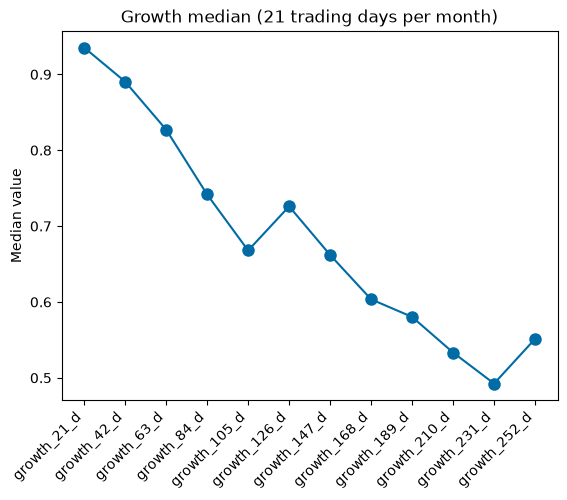

In [73]:
fig, ax = plt.subplots()

ax.plot(
    min_date_stocks_stats.loc["50%"].index, 
    min_date_stocks_stats.loc["50%"].values,
    marker="o",
    markersize=8
)

ax.set_ylabel("Median value")
ax.set_title("Growth median (21 trading days per month)")
ax.tick_params(axis="x", labelrotation=45)
plt.setp(ax.get_xticklabels(), ha="right")

plt.show()

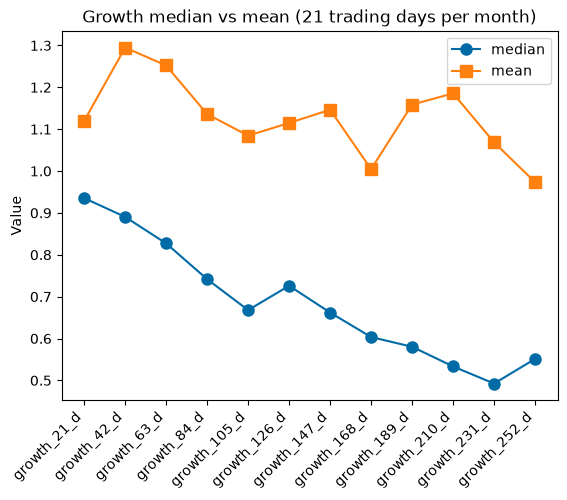

In [74]:
fig, ax = plt.subplots()

ax.plot(
    min_date_stocks_stats.loc["50%"].index, 
    min_date_stocks_stats.loc["50%"].values,
    marker="o",
    markersize=8,
    label="median"
)

ax.plot(
    min_date_stocks_stats.loc["mean"].index, 
    min_date_stocks_stats.loc["mean"].values,
    marker="s",
    markersize=8,
    label="mean"
)

ax.set_ylabel("Value")
ax.set_title("Growth median vs mean (21 trading days per month)")
ax.tick_params(axis="x", labelrotation=45)
plt.setp(ax.get_xticklabels(), ha="right")

ax.legend()
plt.show()

Question 4: [Strategy] Simple RSI-Based Trading Strategy

What is the total profit in `$` thousands you would have earned by investing `$1000` every time a stock was oversold RSI < 30?

Goal:

Apply a simple rule-based trading strategy using the Relative Strength Index (RSI) technical indicator to identify oversold signals and calculate cumulative profits over a 25-year period.

Steps:

Data Acquisition: Use the provided brotli-compressed parquet file containing precomputed technical and macro indicators for a broad set of tickers.

```python
import gdown
import pandas as pd

file_id = "1grCTCzMZKY5sJRtdbLVCXg8JXA8VPyg-"
gdown.download(f"https://drive.google.com/uc?id={file_id}", "data.parquet", quiet=False)
df = pd.read_parquet("data.parquet", engine="pyarrow")
```

Strategy Setup: Define the RSI threshold for an "oversold" signal as RSI < 30.

Filtering: Filter the dataset to isolate trades occurring between 2000-01-01 and 2025-06-01 where the RSI signal was triggered.

Profit Calculation:

  * Assume an investment of $1,000 for every signal.
  * Use the 30-day forward return (growth_future_30d) to determine the outcome of each trade.
  * Calculate Net Income: net_income = 1000 * (selected_df['growth_future_30d'] - 1).sum()

In [75]:
#acquire data
file_id = "1grCTCzMZKY5sJRtdbLVCXg8JXA8VPyg-"
gdown.download(f"https://drive.google.com/uc?id={file_id}", "data.parquet", quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1grCTCzMZKY5sJRtdbLVCXg8JXA8VPyg-
From (redirected): https://drive.google.com/uc?id=1grCTCzMZKY5sJRtdbLVCXg8JXA8VPyg-&confirm=t&uuid=7b669249-e533-40da-8eeb-a1f9942031a7
To: /media/chrisred83/ssd960/git_cleall/python/sm_az_26_lab/homework/hw2/data.parquet
100%|██████████| 130M/130M [00:10<00:00, 12.9MB/s] 


'data.parquet'

In [76]:
#had to explicitly use pyarrow.parquet
#got this error ArrowKeyError: A type extension with name pandas.period already defined
df = pq.read_table("data.parquet").to_pandas()

In [77]:
df.head()

,Open,High,Low,Close_x,Volume,Dividends,Stock Splits,Ticker,Year,Month,...,growth_brent_oil_7d,growth_brent_oil_30d,growth_brent_oil_90d,growth_brent_oil_365d,growth_btc_usd_1d,growth_btc_usd_3d,growth_btc_usd_7d,growth_btc_usd_30d,growth_btc_usd_90d,growth_btc_usd_365d
0,0.054277,0.062259,0.054277,0.059598,1.031789e+09,0.0,0.0,MSFT,1986,1986-03-01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.059598,0.062791,0.059598,0.061726,3.081600e+08,0.0,0.0,MSFT,1986,1986-03-01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.061726,0.063323,0.061726,0.062791,1.331712e+08,0.0,0.0,MSFT,1986,1986-03-01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.062791,0.063323,0.060662,0.061194,6.776640e+07,0.0,0.0,MSFT,1986,1986-03-01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.061194,0.061726,0.059598,0.060130,4.789440e+07,0.0,0.0,MSFT,1986,1986-03-01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [78]:
df[["rsi", "Date"]].head()

,rsi,Date
0,NaN,1986-03-13
1,NaN,1986-03-14
2,NaN,1986-03-17
3,NaN,1986-03-18
4,NaN,1986-03-19


In [79]:
RSI = 30
TRD_INVST = 1000
START_DATE = "2000-01-01"
END_DATE = "2025-06-01"

rsi_df = df[
    (df["rsi"] < RSI) &
    (df["Date"] >= START_DATE) &
    (df["Date"] <= END_DATE)
]

net_income = TRD_INVST * (rsi_df["growth_future_30d"] - 1).sum()
#to thousands
print(net_income/TRD_INVST)

65.80558960747933


Q5. [Exploratory, Optional] Predicting a Positive-Return IPO

Most of the strategies for investing in IPOs deliver negative average and median returns (and even the 75th percentile).

Question: How would you change the strategy if you want to increase profitability?

After investigating what I observed using the available data I found out a strategy that may make sense.

### IPO Short-Term Momentum Strategy (backtest by a practitioner)

Here you can find what I read ([Article](https://www.quantitativo.com/p/the-edge-in-trading-ipos-18-annual)). You can see that the author is bothered by capital utilization, which may be a concern.

  * Core insight: Newly listed stocks exhibit a ~21-day momentum window
  * Buying at an all-time high yields ~3% expected return per trade vs ~1% non IPO stocks making new highs

Considerations

 * The initial underpricing creates a "discovery phase" where institutional investors accumulate over the first few weeks. The all-time-high close is a confirmation that this accumulation is still in progress.
 * On the first trading days (~21) you can find the "sweet spot", beyond that the IPO-specific edge fades.
 * Asymmetric reward to risk, 2:1 proposed reward-to-risk

Steps

  * Companies listed within the past ~90 days (mid/large/mega cap only)
  * (Day-1 Price * Volume ) > 10M in order to avoid liquid names
  * Buy at the open on the day after the stock closes at a new all-time high, deliberately skipping the initial volatility (days 1-2)
  * Profit target +20% (limit order placed same day as entry)
  * Stop-loss -10% (stop order placed same day as entry)
  * Max positions 20
  * If more than 20 signals fire per day, prioritize market cap (largest first)
  * Replace when a target or stop is hit, the freed slot is filled by the next qualifying signal